# 06 — Hyperparameter Tuning and Model Selection

This notebook tunes XGBoost and Random Forest, the two baseline candidates selected in Step 05. Hyperparameters are compared with expanding chronological folds inside the training period. Tuned models are then evaluated on the separate validation period, recall-oriented thresholds are selected using validation data only, and the winning pipeline and threshold are frozen for one-time test evaluation in Step 07. The test set is not loaded or scored here.

In [1]:
from pathlib import Path
from time import perf_counter
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import randint, uniform, loguniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix, f1_score, fbeta_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")
project_root = Path.cwd()
if not (project_root / "data" / "processed").exists():
    project_root = project_root.parent
data_dir = project_root / "data" / "processed"
results_dir = project_root / "reports" / "model_results"
figures_dir = project_root / "reports" / "figures"
models_dir = project_root / "models"
for directory in [results_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

## 1. Load Training and Validation Data

In [2]:
train_df = pd.read_csv(data_dir / "04_train_engineered.csv", parse_dates=["timestamp"])
validation_df = pd.read_csv(data_dir / "04_validation_engineered.csv", parse_dates=["timestamp"])
selected_features = pd.read_csv(results_dir / "04_selected_features.csv")["feature"].tolist()
candidates = pd.read_csv(results_dir / "05_tuning_candidates.csv")["model"].tolist()
if candidates != ["XGBoost", "Random Forest"]:
    raise RuntimeError(f"Unexpected Step 05 candidates: {candidates}")
X_train = train_df[selected_features].copy()
y_train = train_df["failure"].astype("int8").copy()
X_validation = validation_df[selected_features].copy()
y_validation = validation_df["failure"].astype("int8").copy()
print(f"Training: {len(X_train):,} rows, {len(selected_features)} predictors, {y_train.sum():,} failures")
print(f"Validation: {len(X_validation):,} rows, {len(selected_features)} predictors, {y_validation.sum():,} failures")
print("Tuning candidates:", candidates)
print("Test data loaded:", False)

Training: 92,310 rows, 86 predictors, 1,479 failures
Validation: 21,480 rows, 86 predictors, 1,219 failures
Tuning candidates: ['XGBoost', 'Random Forest']
Test data loaded: False


## 2. Expanding Chronological Tuning Folds

Three inner folds use complete timestamp blocks: 55%→15%, 70%→15%, and 85%→15%. Each fold trains only on observations earlier than its assessment window, and all turbines sharing a timestamp remain together. These folds use only the Step 03 training period.

In [3]:
ordered_timestamps = pd.Index(train_df["timestamp"].drop_duplicates().sort_values())
fold_bounds = [(0.55, 0.70), (0.70, 0.85), (0.85, 1.00)]
chronological_cv = []
fold_rows = []
for fold_number, (validation_start_fraction, validation_end_fraction) in enumerate(fold_bounds, start=1):
    start_position = int(np.floor(len(ordered_timestamps) * validation_start_fraction))
    end_position = int(np.floor(len(ordered_timestamps) * validation_end_fraction))
    validation_start = ordered_timestamps[start_position]
    train_indices = np.flatnonzero(train_df["timestamp"].lt(validation_start).to_numpy())
    if end_position < len(ordered_timestamps):
        validation_end = ordered_timestamps[end_position]
        validation_indices = np.flatnonzero(train_df["timestamp"].ge(validation_start).to_numpy() & train_df["timestamp"].lt(validation_end).to_numpy())
    else:
        validation_end = ordered_timestamps[-1]
        validation_indices = np.flatnonzero(train_df["timestamp"].ge(validation_start).to_numpy())
    chronological_cv.append((train_indices, validation_indices))
    fold_rows.append({"fold": fold_number, "training_rows": len(train_indices), "assessment_rows": len(validation_indices), "training_end": train_df.iloc[train_indices]["timestamp"].max(), "assessment_start": train_df.iloc[validation_indices]["timestamp"].min(), "assessment_end": train_df.iloc[validation_indices]["timestamp"].max(), "assessment_failures": int(y_train.iloc[validation_indices].sum())})
fold_report = pd.DataFrame(fold_rows).set_index("fold")
display(fold_report)
print("Every fold is strictly chronological:", all(train_df.iloc[tr]["timestamp"].max() < train_df.iloc[va]["timestamp"].min() for tr, va in chronological_cv))

,training_rows,assessment_rows,training_end,assessment_start,assessment_end,assessment_failures
fold,,,,,,
1,50760,13845,2024-01-24 11:50:00,2024-01-24 12:00:00,2024-01-30 21:40:00,448
2,64605,13845,2024-01-30 21:40:00,2024-01-30 21:50:00,2024-02-06 07:30:00,189
3,78450,13860,2024-02-06 07:30:00,2024-02-06 07:40:00,2024-02-12 17:30:00,358


Every fold is strictly chronological: True


## 3. Randomized Hyperparameter Search

Eight configurations per candidate are evaluated across the three chronological folds. Internal selection prioritizes mean failure recall at threshold 0.50 and uses mean PR-AUC as the tie-breaker. Preprocessing is refitted inside every fold.

In [4]:
categorical_features = ["rated_power_kW"]
numeric_features = [c for c in selected_features if c not in categorical_features]
preprocessor = ColumnTransformer([("numeric", SimpleImputer(strategy="median"), numeric_features), ("rated_power", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features)], remainder="drop", verbose_feature_names_out=False)
scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()
candidate_pipelines = {
    "XGBoost": Pipeline([("preprocessor", preprocessor), ("model", XGBClassifier(objective="binary:logistic", eval_metric="aucpr", scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1))]),
    "Random Forest": Pipeline([("preprocessor", preprocessor), ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))]),
}
parameter_distributions = {
    "XGBoost": {"model__n_estimators": randint(150, 501), "model__max_depth": randint(3, 9), "model__learning_rate": loguniform(0.02, 0.20), "model__min_child_weight": randint(1, 9), "model__subsample": uniform(0.70, 0.30), "model__colsample_bytree": uniform(0.70, 0.30), "model__reg_lambda": loguniform(0.1, 10.0)},
    "Random Forest": {"model__n_estimators": randint(200, 601), "model__max_depth": [8, 12, 16, 20, None], "model__min_samples_split": randint(2, 21), "model__min_samples_leaf": randint(1, 11), "model__max_features": ["sqrt", "log2", 0.5], "model__class_weight": ["balanced", "balanced_subsample"]},
}
scoring = {"recall": "recall", "pr_auc": "average_precision", "roc_auc": "roc_auc"}

In [5]:
search_tables = []
best_parameters = {}
for model_name in candidates:
    started = perf_counter()
    search = RandomizedSearchCV(candidate_pipelines[model_name], parameter_distributions[model_name], n_iter=8, scoring=scoring, refit=False, cv=chronological_cv, random_state=RANDOM_STATE, n_jobs=1, return_train_score=True, error_score="raise")
    search.fit(X_train, y_train)
    table = pd.DataFrame(search.cv_results_)
    table.insert(0, "model", model_name)
    table["recall_gap"] = table["mean_train_recall"] - table["mean_test_recall"]
    table["pr_auc_gap"] = table["mean_train_pr_auc"] - table["mean_test_pr_auc"]
    table = table.sort_values(["mean_test_recall", "mean_test_pr_auc", "recall_gap"], ascending=[False, False, True]).reset_index(drop=True)
    best_parameters[model_name] = table.iloc[0]["params"]
    search_tables.append(table)
    print(f"{model_name}: completed 24 chronological fits in {perf_counter() - started:,.1f} seconds")
    display(table.head(3)[["model", "mean_test_recall", "mean_test_pr_auc", "mean_test_roc_auc", "recall_gap", "pr_auc_gap", "params"]])
tuning_results = pd.concat(search_tables, ignore_index=True)

XGBoost: completed 24 chronological fits in 40.6 seconds


,model,mean_test_recall,mean_test_pr_auc,mean_test_roc_auc,recall_gap,pr_auc_gap,params
0,XGBoost,0.6228,0.7785,0.9920,0.3772,0.2208,{'model__colsample_bytree': 0.9579821220208962...
1,XGBoost,0.6143,0.7817,0.9925,0.3857,0.2183,{'model__colsample_bytree': 0.8123620356542087...
2,XGBoost,0.6061,0.7726,0.9882,0.3939,0.2274,{'model__colsample_bytree': 0.8829989973347863...


Random Forest: completed 24 chronological fits in 217.5 seconds


,model,mean_test_recall,mean_test_pr_auc,mean_test_roc_auc,recall_gap,pr_auc_gap,params
0,Random Forest,0.7330,0.7147,0.9808,0.2670,0.2806,"{'model__class_weight': 'balanced', 'model__ma..."
1,Random Forest,0.6772,0.7639,0.9921,0.3228,0.2334,"{'model__class_weight': 'balanced', 'model__ma..."
2,Random Forest,0.6720,0.7525,0.9922,0.3280,0.2446,"{'model__class_weight': 'balanced', 'model__ma..."


## 4. Tuned Validation Performance and Threshold Selection

Each winning configuration is refitted on the complete training period. A threshold grid from 0.01 to 0.99 is evaluated on validation data. The selected threshold maximizes F2, which weights recall twice as strongly as precision while preventing the trivial all-positive solution. PR-AUC and ROC-AUC remain threshold-independent comparison metrics.

In [6]:
def metrics_at_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype("int8")
    return {"threshold": threshold, "recall": recall_score(y_true, predictions), "precision": precision_score(y_true, predictions, zero_division=0), "f1": f1_score(y_true, predictions), "f2": fbeta_score(y_true, predictions, beta=2, zero_division=0), "predicted_positive_pct": predictions.mean() * 100}

tuned_models = {}
validation_probabilities = {}
threshold_tables = []
comparison_rows = []
threshold_grid = np.round(np.linspace(0.01, 0.99, 197), 3)
for model_name in candidates:
    tuned = clone(candidate_pipelines[model_name]).set_params(**best_parameters[model_name])
    tuned.fit(X_train, y_train)
    probabilities = tuned.predict_proba(X_validation)[:, 1]
    threshold_table = pd.DataFrame([metrics_at_threshold(y_validation, probabilities, threshold) for threshold in threshold_grid])
    threshold_table.insert(0, "model", model_name)
    threshold_table = threshold_table.sort_values(["f2", "recall", "precision"], ascending=False).reset_index(drop=True)
    selected = threshold_table.iloc[0]
    comparison_rows.append({"model": model_name, **selected[["threshold", "recall", "precision", "f1", "f2", "predicted_positive_pct"]].to_dict(), "pr_auc": average_precision_score(y_validation, probabilities), "roc_auc": roc_auc_score(y_validation, probabilities)})
    threshold_tables.append(threshold_table)
    tuned_models[model_name] = tuned
    validation_probabilities[model_name] = probabilities
tuned_comparison = pd.DataFrame(comparison_rows).sort_values(["recall", "pr_auc", "f2"], ascending=False).reset_index(drop=True)
display(tuned_comparison)

,model,threshold,recall,precision,f1,f2,predicted_positive_pct,pr_auc,roc_auc
0,XGBoost,0.0350,0.9122,0.6530,0.7611,0.8451,7.9283,0.8616,0.9892
1,Random Forest,0.1300,0.7801,0.7150,0.7462,0.7662,6.1918,0.6564,0.9771


## 5. Validation Diagnostics and Final Selection

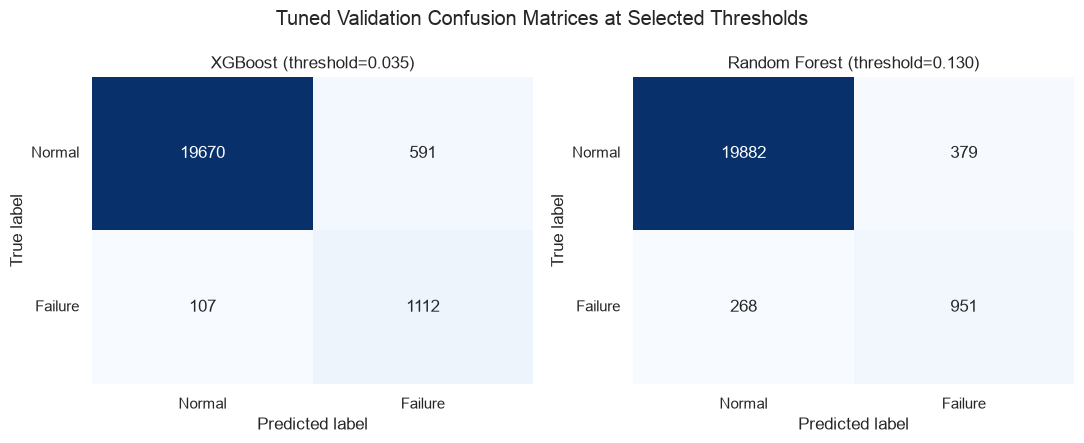

,model,class,precision,recall,f1-score,support
1,XGBoost,failure,0.6530,0.9122,0.7611,"1,219.0000"
3,Random Forest,failure,0.7150,0.7801,0.7462,"1,219.0000"


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
classification_rows = []
for axis, row in zip(axes, tuned_comparison.to_dict("records")):
    model_name = row["model"]
    predictions = (validation_probabilities[model_name] >= row["threshold"]).astype("int8")
    matrix = confusion_matrix(y_validation, predictions)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set(title=f"{model_name} (threshold={row['threshold']:.3f})", xlabel="Predicted label", ylabel="True label")
    axis.set_xticklabels(["Normal", "Failure"]); axis.set_yticklabels(["Normal", "Failure"], rotation=0)
    report = classification_report(y_validation, predictions, target_names=["normal", "failure"], output_dict=True, zero_division=0)
    for class_name in ["normal", "failure"]:
        classification_rows.append({"model": model_name, "class": class_name, **{key: report[class_name][key] for key in ["precision", "recall", "f1-score", "support"]}})
fig.suptitle("Tuned Validation Confusion Matrices at Selected Thresholds")
fig.tight_layout()
figure_path = figures_dir / "06_tuned_validation_confusion_matrices.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
classification_reports = pd.DataFrame(classification_rows)
display(classification_reports.loc[classification_reports["class"] == "failure"].sort_values("recall", ascending=False))

In [8]:
selected_model_name = tuned_comparison.iloc[0]["model"]
selected_threshold = float(tuned_comparison.iloc[0]["threshold"])
for model_name, model in tuned_models.items():
    joblib.dump(model, models_dir / f"06_{model_name.lower().replace(' ', '_')}_tuned.joblib")
joblib.dump(tuned_models[selected_model_name], models_dir / "06_selected_tuned_pipeline.joblib")
with open(models_dir / "06_selected_threshold.json", "w") as file:
    json.dump({"model": selected_model_name, "threshold": selected_threshold, "selection_rule": "validation recall, then PR-AUC and F2; per-model threshold maximizes validation F2"}, file, indent=2)
tuning_export = tuning_results.copy()
tuning_export["params"] = tuning_export["params"].astype(str)
tuning_export.to_csv(results_dir / "06_tuning_results.csv", index=False)
pd.concat(threshold_tables, ignore_index=True).to_csv(results_dir / "06_threshold_results.csv", index=False)
tuned_comparison.to_csv(results_dir / "06_tuned_validation_metrics.csv", index=False)
classification_reports.to_csv(results_dir / "06_tuned_classification_reports.csv", index=False)
print("Selected model:", selected_model_name)
print(f"Frozen threshold: {selected_threshold:.3f}")
print("Test data loaded or scored:", False)

Selected model: XGBoost
Frozen threshold: 0.035
Test data loaded or scored: False


## Key Findings Recap

- XGBoost and Random Forest were each evaluated across eight hyperparameter configurations and three strictly chronological expanding folds, producing 24 training-only tuning fits per model.
- The strongest inner-fold XGBoost configuration achieved 0.6228 mean recall, 0.7785 mean PR-AUC, and 0.9920 mean ROC-AUC at the fixed 0.50 threshold.
- The strongest inner-fold Random Forest configuration achieved 0.7330 mean recall, 0.7147 mean PR-AUC, and 0.9808 mean ROC-AUC at the fixed 0.50 threshold.
- Validation-only F2 optimization selected a 0.035 threshold for tuned XGBoost, producing 0.9122 failure recall, 0.6530 precision, 0.7611 F1, 0.8451 F2, and a 7.9283% predicted-positive rate.
- Random Forest's selected 0.130 threshold produced 0.7801 validation recall, 0.7150 precision, 0.7462 F1, 0.7662 F2, and a 6.1918% predicted-positive rate.
- Tuned XGBoost retained stronger validation ranking performance than tuned Random Forest, with PR-AUC of 0.8616 versus 0.6564 and ROC-AUC of 0.9892 versus 0.9771.
- XGBoost was selected as the final candidate and its 0.035 validation-derived threshold was frozen; both tuned pipelines, search results, threshold diagnostics, classification reports, and confusion matrices were saved.
- The test dataset was neither loaded nor scored, preserving it for the one-time final evaluation in Step 07.